# **DL Lab 9**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)

# **Question 1**

In [3]:
data = pd.read_csv("/content/gold_price.csv")
data = data['Price'].values.reshape(-1, 1)
print(data)

[[  18.93]
 [  18.93]
 [  18.93]
 ...
 [3309.49]
 [3352.66]
 [3340.15]]


In [4]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
print(data_scaled)


[[5.60618779e-04]
 [5.60618779e-04]
 [5.60618779e-04]
 ...
 [9.87057801e-01]
 [1.00000000e+00]
 [9.96249550e-01]]


In [5]:
train_size = int(len(data_scaled)*0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]


In [7]:
def create_sequence(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length +1):
        sequences.append(data[i: i+seq_length])
    return np.array(sequences)

seq_length = 10
train_sequences = create_sequence(train_data, seq_length)
test_sequences = create_sequence(test_data, seq_length)


In [8]:
X_train_full, y_train_full = train_sequences[:, :-1], train_sequences[:, -1]
X_test, y_test = test_sequences[:, :-1], test_sequences[:, -1]
val_fraction = 0.2
val_size = int(len(X_train_full) * val_fraction)
X_val = X_train_full[-val_size:]
y_val = y_train_full[-val_size:]
X_train = X_train_full[:-val_size]
y_train = y_train_full[:-val_size]


In [9]:
model = Sequential()
model.add(SimpleRNN(64, activation='tanh', input_shape=(seq_length-1, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
e_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose = 1)

In [11]:
hist = model.fit(
 X_train, y_train,
 epochs = 500,
 batch_size = 16,
 validation_data = (X_val, y_val),
 verbose = 1,
 callbacks = [e_stop]
)

Epoch 1/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.6601e-05 - val_loss: 2.0329e-04
Epoch 2/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7479e-08 - val_loss: 1.9432e-04
Epoch 3/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.3944e-08 - val_loss: 1.8751e-04
Epoch 4/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.0600e-08 - val_loss: 1.7903e-04
Epoch 5/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9932e-08 - val_loss: 1.6985e-04
Epoch 6/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.9256e-08 - val_loss: 1.6164e-04
Epoch 7/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.1153e-08 - val_loss: 1.5668e-04
Epoch 8/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8846e-08 - val_loss: 1.4752e-04
Epoch 9/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5573e-08 - val_loss: 1.3675e-04
Epoch 10/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5047e-08 - val_loss: 1.2999e-04
Epoch 11/500
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3713e-0

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Root mean Squared Error: 72.26223471534979


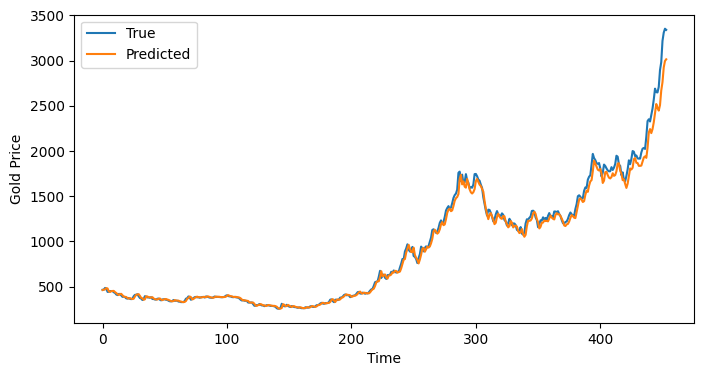

In [12]:
y_pred = model.predict(X_test)
y_test_orig = scaler.inverse_transform(y_test)
y_pred_orig = scaler.inverse_transform(y_pred)
rootmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
print(f"Root mean Squared Error: {rootmse}")
plt.figure(figsize=(8,4))
plt.plot(y_test_orig, label="True")
plt.plot(y_pred_orig, label="Predicted")
plt.xlabel('Time')
plt.ylabel('Gold Price')
plt.legend()
plt.show()


# **Question 2**


In [13]:
data = pd.read_csv("gold_price.csv")
data = data['Price'].values.reshape(-1, 1)
print(data)

[[  18.93]
 [  18.93]
 [  18.93]
 ...
 [3309.49]
 [3352.66]
 [3340.15]]


In [14]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [15]:
print(data_scaled)

[[5.60618779e-04]
 [5.60618779e-04]
 [5.60618779e-04]
 ...
 [9.87057801e-01]
 [1.00000000e+00]
 [9.96249550e-01]]


In [16]:
train_size = int(len(data_scaled)*0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [19]:
def create_sequence_len(data, input_len = 10, output_len = 10):
    X, y = [], []
    for i in range(len(data) - input_len - output_len +1):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len: i+input_len + output_len])
    return np.array(X), np.array(y)
input_len = 10
output_len = 10

In [26]:
model2 = Sequential()
model2.add(SimpleRNN(64, activation='tanh', return_sequences=True, input_shape=(input_len, 1)))
model2.add(TimeDistributed(Dense(1)))
model2.compile(optimizer = "adam", loss = "mean_squared_error")
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 10, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
X_train_full, y_train_full = create_sequence_len(train_data, input_len, output_len)
X_test, y_test = create_sequence_len(test_data, input_len, output_len)
val_fraction = 0.2
val_size = int(len(X_train_full) * val_fraction)
X_val = X_train_full[-val_size:]
y_val = y_train_full[-val_size:]
X_train = X_train_full[:-val_size]
y_train = y_train_full[:-val_size]

In [25]:
e_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose = 1)


In [31]:
hist2 = model2.fit(
 X_train, y_train,
 epochs = 100,
 batch_size = 16,
 validation_data = (X_val, y_val),
 verbose = 1,
 callbacks = [e_stop]
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2329e-07 - val_loss: 4.2806e-04
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6220e-07 - val_loss: 4.2880e-04
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7070e-07 - val_loss: 4.2051e-04
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9995e-07 - val_loss: 4.2014e-04
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5012e-07 - val_loss: 4.2111e-04
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.3036e-07 - val_loss: 4.2472e-04
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4245e-07 - val_loss: 4.2012e-04
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5169e-07 - val_loss: 4.2082e-04
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3090e-07 - val_loss: 4.2198e-04
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2366e-07 - val_loss: 4.2731e-04
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4409e-0

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Root mean Squared Error for model2: 179.5156235298048


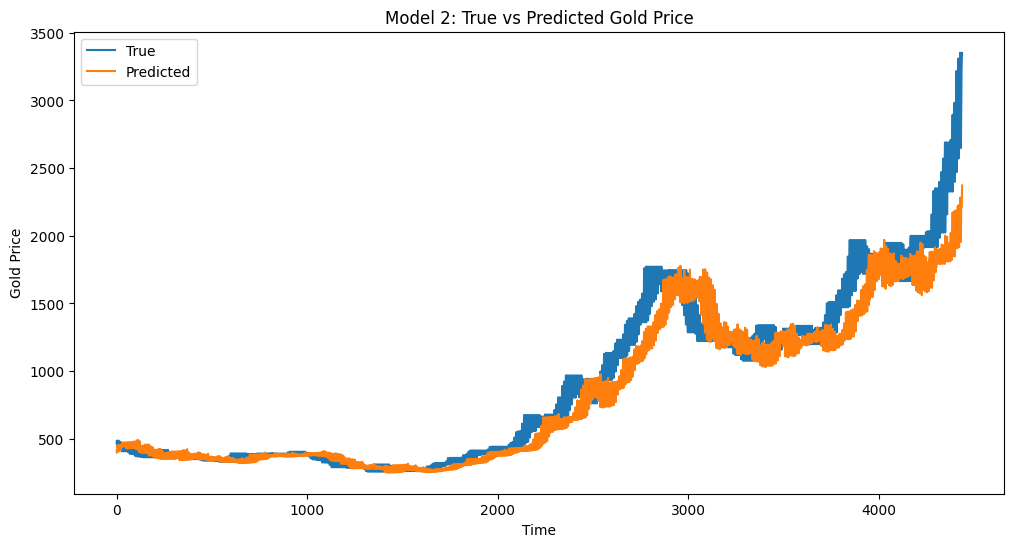

In [33]:
y_pred2 = model2.predict(X_test)

y_test_orig2 = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_orig2 = scaler.inverse_transform(y_pred2.reshape(-1, 1))

rootmse2 = np.sqrt(mean_squared_error(y_test_orig2, y_pred_orig2))
print(f"Root mean Squared Error for model2: {rootmse2}")

plt.figure(figsize=(12, 6))
plt.plot(y_test_orig2[:, 0], label="True")
plt.plot(y_pred_orig2[:, 0], label="Predicted")
plt.xlabel('Time')
plt.ylabel('Gold Price')
plt.title('Model 2: True vs Predicted Gold Price')
plt.legend()
plt.show()


# **Question 3**

In [34]:
model3 = Sequential()
model3.add(SimpleRNN(128, activation='tanh', return_sequences=True, input_shape=(input_len, 1)))
model3.add(SimpleRNN(64, activation='tanh', return_sequences=True))
model3.add(SimpleRNN(32, activation='tanh', return_sequences=True))
model3.add(Dense(1))
model3.compile(optimizer='adam', loss='mean_squared_error')
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 10, 128)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 10, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 10, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10, 1)          │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,129 (125.50 KB)

 Trainable params: 32,129 (125.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
hist3 = model3.fit(
 X_train, y_train,
 epochs = 100,
 batch_size = 16,
 validation_data = (X_val, y_val),
 verbose = 1,
 callbacks = [e_stop]
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 8.2065e-04 - val_loss: 0.0015
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1246e-06 - val_loss: 9.0088e-04
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.5771e-07 - val_loss: 6.8716e-04
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.2278e-07 - val_loss: 5.9312e-04
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2116e-07 - val_loss: 5.4587e-04
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.1359e-07 - val_loss: 5.1904e-04
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 2.0819e-07 - val_loss: 5.0089e-04
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6959e-07 - val_loss: 4.8747e-04
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.7968e-07 - val_loss: 4.7750e-04
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.7200e-07 - val_loss: 4.6639e-04
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Root mean Squared Error for model3: 179.5156235298048


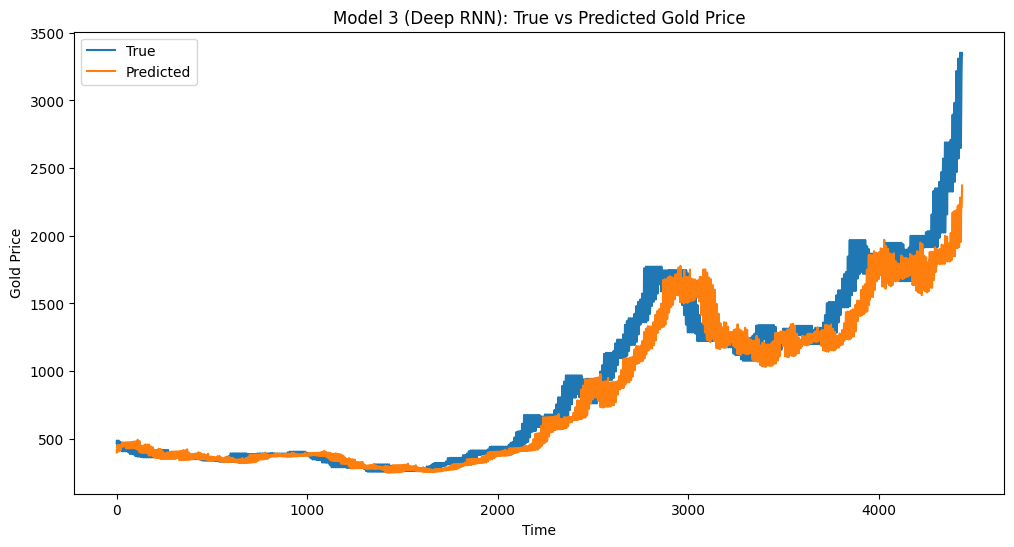

In [36]:
y_pred3 = model3.predict(X_test)

y_test_orig3 = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_orig3 = scaler.inverse_transform(y_pred2.reshape(-1, 1))

rootmse3 = np.sqrt(mean_squared_error(y_test_orig3, y_pred_orig3))
print(f"Root mean Squared Error for model3: {rootmse3}")

plt.figure(figsize=(12, 6))
plt.plot(y_test_orig2[:, 0], label="True")
plt.plot(y_pred_orig2[:, 0], label="Predicted")
plt.xlabel('Time')
plt.ylabel('Gold Price')
plt.title('Model 3 (Deep RNN): True vs Predicted Gold Price')
plt.legend()
plt.show()